In [2]:
from itertools import combinations
import pandas as pd
from math import comb

In [3]:
df = pd.read_parquet('../data/processed/iran_cinema_clean.parquet')
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,ordering,nconst,category,primaryName
0,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",1,nm0798270,actor,David Silva
1,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",2,nm0739131,actress,Titina Romay
2,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",3,nm0327643,actress,Carmelita González
3,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",4,nm0273508,actor,Freddy Fernández
4,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",5,nm0414109,actor,Tonina Jackson


In [4]:
df_names_full = pd.read_csv('../data/raw/name.basics.tsv.gz', sep='\t', usecols=['nconst', 'birthYear', 'deathYear'])
df_check = df.merge(df_names_full, on='nconst', how='left')

df_check['deathYear'] = pd.to_numeric(df_check['deathYear'], errors='coerce')

# drop people who died before the film creation 
posthumous = df_check[df_check['deathYear'] < df_check['startYear']]
print(posthumous[['primaryName', 'primaryTitle', 'deathYear', 'startYear']].drop_duplicates().shape)

(0, 4)


In [5]:
invalid_nconsts = set(posthumous['nconst'])
df = df[~df['nconst'].isin(invalid_nconsts)]
print(df.shape)

(73242, 13)


یافتن جفت های همکاری 

In [6]:
collaboration_pairs = []

for tconst, group in df.groupby('tconst'):
    people = group[['nconst', 'primaryName']].drop_duplicates().values.tolist()
    n = len(people)
    if n < 2:
        continue
    
    weight = 1 / comb(n, 2)  
    
    for (p1, n1), (p2, n2) in combinations(people, 2):
        collaboration_pairs.append({
            'tconst': tconst,
            'person1': p1, 'name1': n1,
            'person2': p2, 'name2': n2,
            'weight': weight
        })

df_pairs = pd.DataFrame(collaboration_pairs)
print(df_pairs.shape)
df_pairs.head()

(301594, 6)


,tconst,person1,name1,person2,name2,weight
0,tt0044728,nm0798270,David Silva,nm0739131,Titina Romay,0.012821
1,tt0044728,nm0798270,David Silva,nm0327643,Carmelita González,0.012821
2,tt0044728,nm0798270,David Silva,nm0273508,Freddy Fernández,0.012821
3,tt0044728,nm0798270,David Silva,nm0414109,Tonina Jackson,0.012821
4,tt0044728,nm0798270,David Silva,nm0349467,Anabelle Gutiérrez,0.012821


In [7]:
df_pairs.to_parquet('../data/processed/collaboration_pairs.parquet')

In [6]:
pairs_long = pd.concat([
    df_pairs[['person1', 'name1', 'person2', 'weight', 'tconst']].rename(columns={'person1':'nconst','name1':'primaryName','person2':'collaborator'}),
    df_pairs[['person2', 'name2', 'person1', 'weight', 'tconst']].rename(columns={'person2':'nconst','name2':'primaryName','person1':'collaborator'})
])

print(pairs_long.shape)
pairs_long.head()

(603188, 5)


,nconst,primaryName,collaborator,weight,tconst
0,nm0798270,David Silva,nm0739131,0.012821,tt0044728
1,nm0798270,David Silva,nm0327643,0.012821,tt0044728
2,nm0798270,David Silva,nm0273508,0.012821,tt0044728
3,nm0798270,David Silva,nm0414109,0.012821,tt0044728
4,nm0798270,David Silva,nm0349467,0.012821,tt0044728


 افراد با بیشترین تعداد همکاری

In [7]:
metrics = pairs_long.groupby(['nconst', 'primaryName']).agg(
    work_count=('tconst', 'nunique'),
    unique_collaborators=('collaborator', 'nunique'),
    total_collaborations=('collaborator', 'count')
).reset_index()

metrics.sort_values('total_collaborations', ascending=False).head(10)

,nconst,primaryName,work_count,unique_collaborators,total_collaborations
694,nm0451571,Hamideh Kheirabadi,167,742,1568
10600,nm2465620,Mehdi Aminikhah,148,829,1252
9002,nm1714957,Kianoosh Gerami,136,772,1247
1603,nm1028434,Reza Beyk Imanverdi,121,465,1164
4002,nm1286513,Kazem Afrandnia,126,766,1162
11368,nm2932763,Siamak Ash'arioon,128,720,1158
12837,nm5747379,Heshmatollah Aramideh,123,761,1120
1032,nm0707308,Mehran Rajabi,115,736,1049
9762,nm1824944,Ali Miri,104,428,1044
24,nm0008206,Akbar Abdi,107,712,1003


HHI metric

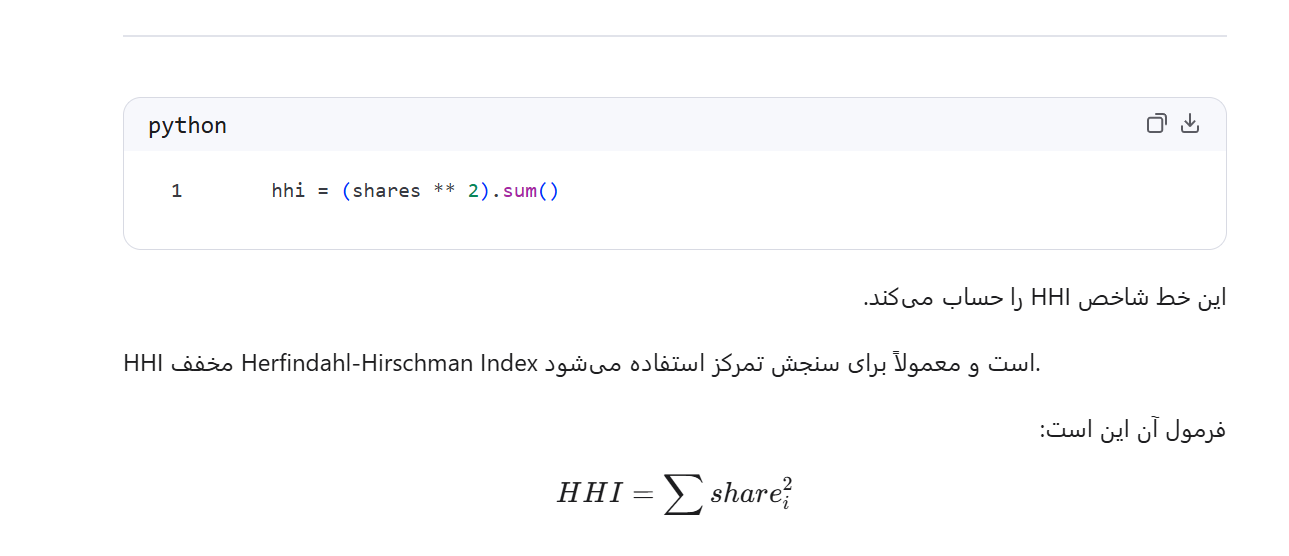

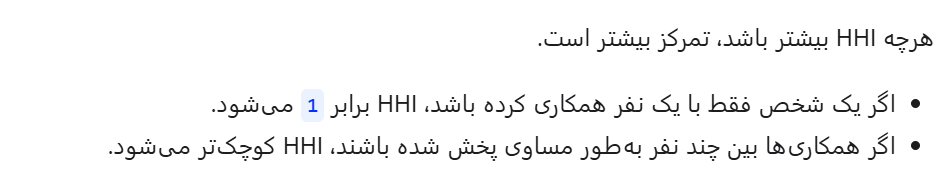

In [8]:
pair_counts = pairs_long.groupby(['nconst', 'primaryName', 'collaborator']).size().reset_index(name='pair_collab_count')
pair_counts.head()

,nconst,primaryName,collaborator,pair_collab_count
0,nm0000695,Joanne Whalley,nm0039162,1
1,nm0000695,Joanne Whalley,nm0117991,1
2,nm0000695,Joanne Whalley,nm0147062,1
3,nm0000695,Joanne Whalley,nm0152650,1
4,nm0000695,Joanne Whalley,nm0160467,1


In [9]:
def compute_hhi(group):
    shares = group['pair_collab_count'] / group['pair_collab_count'].sum()
    hhi = (shares ** 2).sum()
    top_share = shares.max()
    return pd.Series({'hhi': hhi, 'top_collaborator_share': top_share})

concentration = pair_counts.groupby(['nconst', 'primaryName']).apply(compute_hhi).reset_index()
concentration.head()

C:\Users\Rahas\AppData\Local\Temp\ipykernel_21568\3381247091.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  concentration = pair_counts.groupby(['nconst', 'primaryName']).apply(compute_hhi).reset_index()


,nconst,primaryName,hhi,top_collaborator_share
0,nm0000695,Joanne Whalley,0.090909,0.090909
1,nm0001094,Roald Dahl,0.200000,0.200000
2,nm0001120,Vittorio De Sica,0.076923,0.076923
3,nm0001393,Irène Jacob,0.090909,0.090909
4,nm0001411,William Katt,0.090909,0.090909


Career Length

In [10]:
career = df.groupby('nconst').agg(
    max_year=('startYear', 'max'),   
    min_year=('startYear', 'min')
).reset_index()                     

career['career_length'] = career['max_year'] - career['min_year'] + 1
career.head()

,nconst,max_year,min_year,career_length
0,nm0000695,2009,2009,1
1,nm0001094,1990,1990,1
2,nm0001120,1960,1960,1
3,nm0001393,2012,2012,1
4,nm0001411,1982,1982,1


works per active year

In [11]:
metrics = metrics.merge(concentration[['nconst', 'hhi', 'top_collaborator_share']], on='nconst', how='left')
metrics = metrics.merge(career[['nconst', 'career_length']], on='nconst', how='left')
metrics['works_per_active_year'] = metrics['work_count'] / metrics['career_length']

In [12]:
metrics.to_parquet('../data/processed/person_collaboration_metrics.parquet')

In [13]:
df[df['nconst'] == 'nm0000636'][['tconst', 'primaryTitle', 'originalTitle', 'category']].drop_duplicates()

,tconst,primaryTitle,originalTitle,category


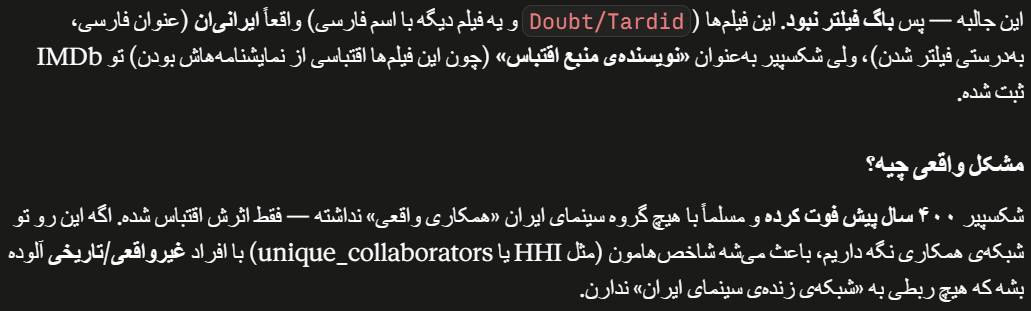

In [14]:
df[df['nconst'] == 'nm0001094'][['tconst', 'primaryTitle', 'originalTitle']].drop_duplicates()

,tconst,primaryTitle,originalTitle
5742,tt0399655,The Silent Hunt,Shekare khamoosh


In [15]:
df.to_parquet('../data/processed/iran_cinema_clean.parquet')

In [16]:
metrics.to_parquet('../data/processed/person_collaboration_metrics.parquet')

In [17]:
print(metrics.columns.tolist())

['nconst', 'primaryName', 'work_count', 'unique_collaborators', 'total_collaborations', 'hhi', 'top_collaborator_share', 'career_length', 'works_per_active_year']
